# 04 - Avaliação e exportação para o Power BI

Um único período de teste pode enganar. Aqui repetimos o experimento com cortes em dez/2021,
dez/2022 e dez/2023 (cada um testando os 12 meses seguintes), escolhemos o modelo final e geramos os
arquivos do dashboard.

Equivale a rodar `train_model`, `evaluate` e `predict_model` pela linha de comando.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

from src.config import POWERBI_DIR, FIGURES_DIR
from src.models import train_model, evaluate, predict_model

In [2]:
train_model.main()
evaluate.main()

15:01:45 | INFO | src.models.train_model | Treino: 5912 linhas (alvo até 2024-12-01) | Teste: 943 linhas (base a partir de 2024-12-01)


15:01:45 | INFO | src.models.train_model | ridge treinado


15:01:49 | INFO | src.models.train_model | random_forest treinado


15:01:50 | INFO | src.models.train_model | gradient_boosting treinado


15:01:50 | INFO | src.models.evaluate | Teste principal (corte 2024-12-01):
     corte            modelo  mae_usd  mape  wape  vies_pct  ganho_vs_ingenuo_pct  series_melhor_que_ingenuo_pct
2024-12-01 gradient_boosting    0.179 3.840 3.896    -0.612                 9.059                         68.333
2024-12-01           ingenuo    0.197 4.294 4.284    -0.807                 0.000                            NaN
2024-12-01     random_forest    0.177 3.880 3.853    -0.342                10.068                         73.333
2024-12-01             ridge    0.195 4.248 4.237    -0.056                 1.104                         53.333
2024-12-01   sazonal_ingenuo    0.233 5.159 5.065    -0.007               -18.239                         21.667


15:01:54 | INFO | src.models.evaluate | Backtest corte 2021-12-01: 688 linhas de teste


15:01:57 | INFO | src.models.evaluate | Backtest corte 2022-12-01: 720 linhas de teste


15:02:02 | INFO | src.models.evaluate | Backtest corte 2023-12-01: 720 linhas de teste


15:02:02 | INFO | src.models.evaluate | Arquivos de avaliação salvos em data/processed/powerbi/


## Backtest

In [3]:
met = pd.read_csv(POWERBI_DIR / "metricas_modelos.csv")
tab = met.pivot(index="modelo", columns="corte", values="wape").round(2)
tab["media"] = tab.mean(axis=1).round(2)
tab.sort_values("media")

corte,2021-12-01,2022-12-01,2023-12-01,2024-12-01,media
modelo,,,,,
gradient_boosting,4.74,3.91,2.88,3.90,3.86
random_forest,4.98,3.86,2.98,3.85,3.92
ingenuo,4.98,3.90,3.16,4.28,4.08
ridge,5.29,4.14,3.08,4.24,4.19
sazonal_ingenuo,6.37,6.14,4.29,5.07,5.47


In [4]:
met.pivot(index="modelo", columns="corte", values="ganho_vs_ingenuo_pct").round(1)

corte,2021-12-01,2022-12-01,2023-12-01,2024-12-01
modelo,,,,
gradient_boosting,4.8,-0.2,8.8,9.1
ingenuo,0.0,0.0,0.0,0.0
random_forest,-0.0,1.2,5.8,10.1
ridge,-6.1,-6.1,2.6,1.1
sazonal_ingenuo,-27.8,-57.3,-35.9,-18.2


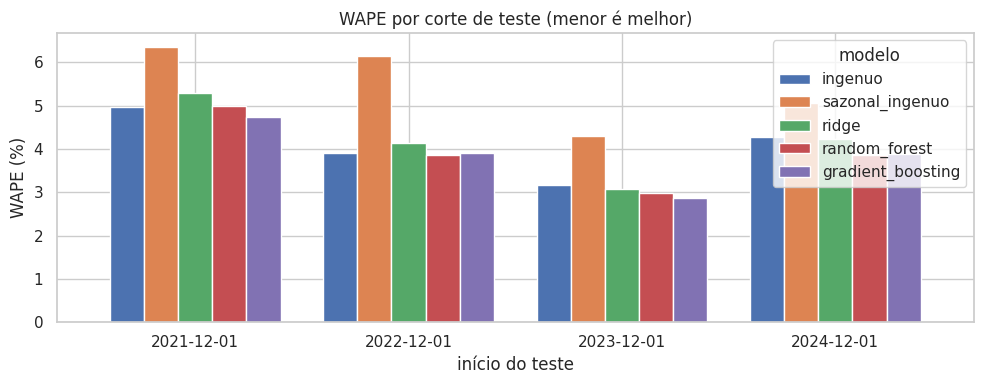

In [5]:
ordem = ["ingenuo", "sazonal_ingenuo", "ridge", "random_forest", "gradient_boosting"]
ax = met.pivot(index="corte", columns="modelo", values="wape")[ordem].plot(kind="bar", figsize=(10, 4), width=0.8)
ax.set_title("WAPE por corte de teste (menor é melhor)")
ax.set_ylabel("WAPE (%)")
ax.set_xlabel("início do teste")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_backtest_wape.png", dpi=120)

Leitura:

- O **gradient boosting** tem o menor WAPE médio (3,86% contra 4,08% do ingênuo, ganho de ~5%). Ganha em três dos quatro cortes e empata no de dez/2022.
- O corte de dez/2022 testa 2023, o ano em que a inflação desacelerou de repente. Features de tendência (ret_3, ret_6) apontavam para continuar subindo e nenhum modelo conseguiu superar o ingênuo com folga.
- O **random forest** foi o melhor no teste principal (10% de ganho), mas empatou com o ingênuo em 2021/22. Menos estável.
- **Ridge** perde para o ingênuo em dois cortes: a relação é não linear (sazonalidade só importa para algumas categorias).
- **Sazonal ingênuo** é sempre o pior. Repetir o ano anterior inteiro carrega junto os choques daquele ano.

## Modelo final e previsão

In [6]:
predict_model.main()
fut = pd.read_csv(POWERBI_DIR / "previsao_futura.csv", parse_dates=["data_base", "data_alvo"])
fut.groupby("categoria")["variacao_prevista_pct"].median().sort_values().round(2)

15:02:02 | INFO | src.models.predict_model | WAPE médio nos cortes:
modelo
gradient_boosting    3.858
random_forest        3.917
ridge                4.186


15:02:02 | INFO | src.models.predict_model | Modelo final: gradient_boosting


15:02:03 | WARNING | src.features.build_features | Sem previsão (dados recentes incompletos): Lettuce, romaine


15:02:03 | INFO | src.models.predict_model | Previsão para 59 séries (alvo mais comum: 2026-10-01)


15:02:03 | INFO | src.models.predict_model | dim_item (74), fato_precos (8970) e sazonalidade exportados


categoria
Energia           -6.00
Hortaliças        -2.14
Carne bovina      -0.48
Padaria e grãos   -0.04
Bebidas           -0.02
Suínos e frios     0.04
Aves               0.12
Mercearia          0.60
Laticínios         1.03
Frutas             1.10
Ovos               1.45
Name: variacao_prevista_pct, dtype: float64

In [7]:
cols = ["item", "preco_base", "preco_previsto", "faixa_inferior", "faixa_superior", "variacao_prevista_pct"]
pd.concat([fut.nsmallest(5, "variacao_prevista_pct"), fut.nlargest(5, "variacao_prevista_pct")])[cols]

,item,preco_base,preco_previsto,faixa_inferior,faixa_superior,variacao_prevista_pct
33,Automotive diesel fuel,5.077,4.288,4.081,5.659,-15.54
39,"Gasoline, unleaded regular",4.094,3.715,3.536,4.903,-9.26
46,Fuel oil #2,4.799,4.376,4.165,5.776,-8.80
40,"Tomatoes, field grown",2.003,1.855,1.708,1.957,-7.39
22,"Gasoline, unleaded premium",5.027,4.712,4.484,6.219,-6.26
20,"Strawberries, dry pint",2.404,2.877,2.713,3.069,19.70
2,"Oranges, Navel",1.540,1.693,1.596,1.806,9.93
25,"Butter, stick",3.922,4.110,3.849,4.243,4.80
1,"Chops, center cut, bone-in",4.905,5.054,4.851,5.192,3.04
27,"Beef for stew, boneless",9.025,9.193,8.958,9.853,1.86


## Arquivos gerados para o Power BI

In [8]:
for arq in sorted(POWERBI_DIR.glob("*.csv")):
    print(f"{arq.name:32s} {len(pd.read_csv(arq)):>6} linhas")

dim_item.csv                         74 linhas
fato_precos.csv                    8970 linhas
metricas_modelos.csv                 20 linhas
metricas_por_categoria.csv           55 linhas
metricas_por_item.csv               300 linhas
previsao_futura.csv                  59 linhas
previsoes_teste.csv                4715 linhas
sazonalidade.csv                    888 linhas


## Conclusões

1. Prever preço de alimento 3 meses à frente é difícil: o ingênuo já erra só ~4%. O modelo final reduz esse erro em ~5% na média dos quatro cortes e ~9% no teste mais recente. Ganho modesto, mas consistente.
2. O ganho está concentrado onde há estrutura: **frutas** (sazonalidade, -43% de erro), **ovos** (-15%) e **carne bovina** (-13%). Em categorias paradas (aves, padaria, bebidas, laticínios) o ingênuo é melhor ou igual; no dashboard isso aparece por categoria.
3. A previsão para out/2026 indica **queda de energia** (diesel -15%, gasolina -9%) depois da alta do primeiro semestre, e alta sazonal de morango e laranja. A faixa de energia é assimétrica (até +32%) porque no teste o modelo subestimou justamente essa alta: ele tende a apostar em reversão.
4. Limitações: preços nominais (sem desconto da inflação), média nacional, e a faixa é empírica (quantis do erro no teste), não um intervalo de confiança formal.